In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

np.random.seed(0)   # reproducibilidad (el sistema es determinista)

g = 3
conjuntos = {1: (0.5, 0.6), 2: (1.4, 1.5), 3: (0.6, 1.5), 4: (1.5, 0.6)}
conj = ((g - 1) % 4) + 1
a, b = conjuntos[conj]            # a = alpha12, b = alpha21
r1 = 1.0
r2 = 0.5 + 0.1 * ((g - 1) % 5)
print(f"g = {g} | conjunto {conj} | alpha12 = {a}, alpha21 = {b} | r1 = {r1}, r2 = {r2:.1f}")

P = {'P1': (0.05, 0.05), 'P2': (0.80, 0.30), 'P3': (0.30, 0.80), 'P4': (0.60, 0.60)}

def make_f(a, b, r1, r2):
    def f(s):
        x, y = s
        return np.array([r1 * x * (1 - x - a * y), r2 * y * (1 - y - b * x)])
    return f

f = make_f(a, b, r1, r2)

def euler(f, s0, h, T):
    s = np.array(s0, float)
    for _ in range(int(round(T / h))):
        s = s + h * f(s)
    return s

def rk4_step(f, s, h):
    k1 = f(s); k2 = f(s + h/2*k1); k3 = f(s + h/2*k2); k4 = f(s + h*k3)
    return s + h/6 * (k1 + 2*k2 + 2*k3 + k4)

def rk4(f, s0, h, T):
    s = np.array(s0, float)
    for _ in range(int(round(T / h))):
        s = rk4_step(f, s, h)
    return s

def rk4_traj(f, s0, h, T):
    s = np.array(s0, float); out = [s.copy()]
    for _ in range(int(round(T / h))):
        s = rk4_step(f, s, h); out.append(s.copy())
    return np.array(out)

g = 3 | conjunto 3 | alpha12 = 0.6, alpha21 = 1.5 | r1 = 1.0, r2 = 0.7


## Task 1: verificación numérica de los cálculos a mano

Equilibrio interior: x\* = (1 − α₁₂)/(1 − α₁₂α₂₁), y\* = (1 − α₂₁)/(1 − α₁₂α₂₁).  
Jacobiana: J = [[r₁(1 − 2x − α₁₂y), −r₁α₁₂x], [−r₂α₂₁y, r₂(1 − 2y − α₂₁x)]].

equilibrio   x    y  factible   tau  Delta  tau^2-4Delta            lambda          clase
     (0,0) 0.0  0.0      True  1.70   0.70        0.0900        [1.0, 0.7] nodo inestable
     (1,0) 1.0  0.0      True -1.35   0.35        0.4225     [-1.0, -0.35]   nodo estable
     (0,1) 0.0  1.0      True -0.30  -0.28        1.2100       [-0.7, 0.4]          silla
  interior 4.0 -5.0     False -0.50  -1.40        5.8500 [-1.4593, 0.9593]          silla


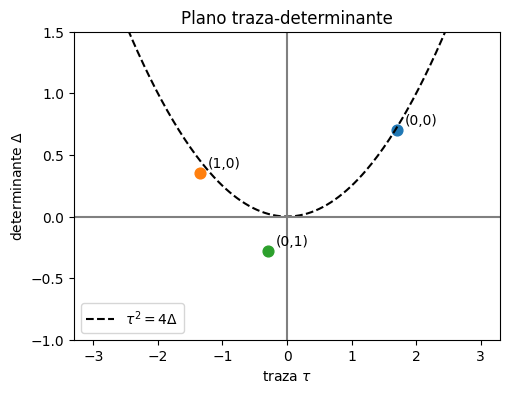

In [2]:
den = 1 - a * b
eqs = {'(0,0)': (0, 0), '(1,0)': (1, 0), '(0,1)': (0, 1), 'interior': ((1 - a) / den, (1 - b) / den)}

def jac(x, y, a=a, b=b, r1=r1, r2=r2):
    return np.array([[r1 * (1 - 2*x - a*y), -r1 * a * x],
                     [-r2 * b * y,          r2 * (1 - 2*y - b*x)]])

def clasifica(tau, D, disc):
    if D < 0: return 'silla'
    if tau == 0: return 'centro'
    tipo = 'nodo' if disc >= 0 else 'foco'
    return f"{tipo} {'estable' if tau < 0 else 'inestable'}"

rows = []
for n, (x, y) in eqs.items():
    J = jac(x, y); tau = np.trace(J); D = np.linalg.det(J); disc = tau**2 - 4*D
    rows.append({'equilibrio': n, 'x': x, 'y': y, 'factible': (x >= 0 and y >= 0),
                 'tau': tau, 'Delta': D, 'tau^2-4Delta': disc,
                 'lambda': np.round(np.linalg.eigvals(J), 4), 'clase': clasifica(tau, D, disc)})
df = pd.DataFrame(rows)
print(df.round(4).to_string(index=False))

# Plano traza-determinante de los equilibrios factibles
fig, ax = plt.subplots(figsize=(5.5, 4))
t = np.linspace(-3, 3, 200); ax.plot(t, t**2 / 4, 'k--', label=r'$\tau^2=4\Delta$')
ax.axhline(0, color='gray'); ax.axvline(0, color='gray')
for _, r in df[df.factible].iterrows():
    ax.scatter(r.tau, r.Delta, s=60); ax.annotate(r.equilibrio, (r.tau, r.Delta), textcoords='offset points', xytext=(6, 4))
ax.set_xlabel(r'traza $\tau$'); ax.set_ylabel(r'determinante $\Delta$'); ax.set_ylim(-1, 1.5); ax.legend(); ax.set_title('Plano traza-determinante')
plt.show()

### Task 1.4: análisis del compañero (α₁₂ = 1.4, α₂₁ = 1.5, r₁ = 1, r₂ = 0.8)

El error es usar Δ = J₁₁J₂₂ **+** J₁₂J₂₁. El determinante es Δ = J₁₁J₂₂ **−** J₁₂J₂₁.

In [3]:
a4, b4, r24 = 1.4, 1.5, 0.8
d4 = 1 - a4 * b4
xs4, ys4 = (1 - a4) / d4, (1 - b4) / d4
J4 = jac(xs4, ys4, a4, b4, 1.0, r24)
tau4, D4 = np.trace(J4), np.linalg.det(J4)
print("equilibrio interior:", round(xs4, 3), round(ys4, 3))
print("J =\n", J4.round(3))
print("Delta (compañero, con +) =", round(J4[0,0]*J4[1,1] + J4[0,1]*J4[1,0], 3))
print("Delta correcto           =", round(D4, 3), "| cerrado r1 r2 x* y* (1-ab) =", round(1*r24*xs4*ys4*d4, 3))
print("tau =", round(tau4, 3), "| tau^2-4Delta =", round(tau4**2 - 4*D4, 3), "| lambda =", np.linalg.eigvals(J4).round(3))
print("clasificación:", clasifica(tau4, D4, tau4**2 - 4*D4))

equilibrio interior: 0.364 0.455
J =
 [[-0.364 -0.509]
 [-0.545 -0.364]]
Delta (compañero, con +) = 0.41
Delta correcto           = -0.145 | cerrado r1 r2 x* y* (1-ab) = -0.145
tau = -0.727 | tau^2-4Delta = 1.111 | lambda = [ 0.163 -0.891]
clasificación: silla


## Task 2.1: Euler y Runge-Kutta 4 desde cero

Referencia: `solve_ivp` con DOP853, rtol = atol = 10⁻¹², estado P2, T = 10.

referencia: [0.99015243 0.01065375]
     h  error Euler    error RK4
0.2000     0.001578 8.132976e-09
0.1000     0.000793 4.968907e-10
0.0500     0.000398 3.080917e-11
0.0250     0.000199 2.038127e-12
0.0125     0.000100 2.961110e-13
pendiente Euler = 0.996 (teoría 1)
pendiente RK4   = 3.742 con los 5 pasos | 3.990 con los 4 primeros (teoría 4)
razones RK4 entre pasos consecutivos (log2): [4.03 4.01 3.92 2.78]


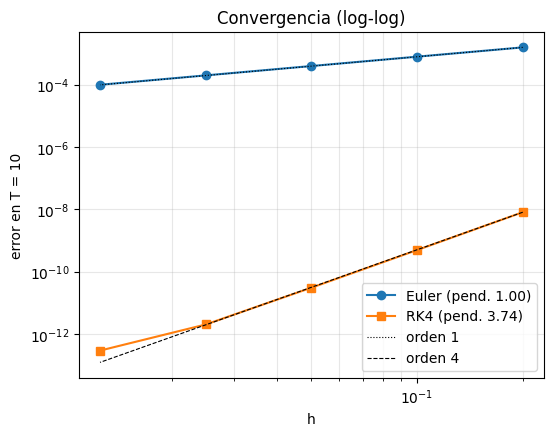

In [4]:
T = 10.0
ref = solve_ivp(lambda t, s: f(s), [0, T], P['P2'], method='DOP853', rtol=1e-12, atol=1e-12).y[:, -1]
hs = np.array([0.2, 0.1, 0.05, 0.025, 0.0125])
eE = np.array([np.linalg.norm(euler(f, P['P2'], h, T) - ref) for h in hs])
eR = np.array([np.linalg.norm(rk4(f, P['P2'], h, T) - ref) for h in hs])

print("referencia:", ref)
print(pd.DataFrame({'h': hs, 'error Euler': eE, 'error RK4': eR}).to_string(index=False))

pE = np.polyfit(np.log(hs), np.log(eE), 1)[0]
pR = np.polyfit(np.log(hs), np.log(eR), 1)[0]
pR4 = np.polyfit(np.log(hs[:4]), np.log(eR[:4]), 1)[0]
print(f"pendiente Euler = {pE:.3f} (teoría 1)")
print(f"pendiente RK4   = {pR:.3f} con los 5 pasos | {pR4:.3f} con los 4 primeros (teoría 4)")
print("razones RK4 entre pasos consecutivos (log2):", np.round(np.log2(eR[:-1] / eR[1:]), 2))

plt.figure(figsize=(6, 4.5))
plt.loglog(hs, eE, 'o-', label=f'Euler (pend. {pE:.2f})')
plt.loglog(hs, eR, 's-', label=f'RK4 (pend. {pR:.2f})')
plt.loglog(hs, eE[0] * (hs / hs[0]), 'k:', lw=.8, label='orden 1'); plt.loglog(hs, eR[0] * (hs / hs[0])**4, 'k--', lw=.8, label='orden 4')
plt.xlabel('h'); plt.ylabel('error en T = 10'); plt.legend(); plt.grid(True, which='both', alpha=.3); plt.title('Convergencia (log-log)')
plt.show()

**Desviación del RK4:** el error del último paso llega a ~3×10⁻¹³, cerca del piso de la referencia (tol 10⁻¹²) y del redondeo, y eso aplana la recta. Con los primeros cuatro pasos la pendiente es ≈ 4.

## Task 2.2: retrato de fases y comparación con las predicciones

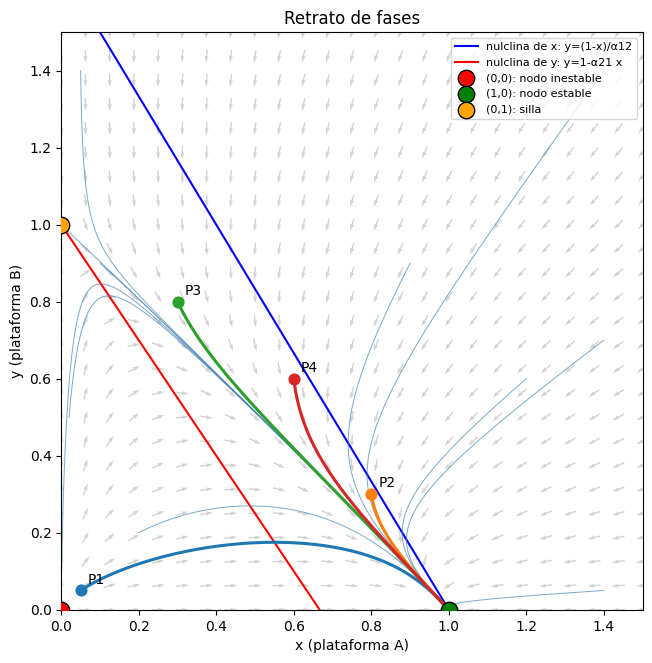

punto predicción simulación estado final  coincide
   P1      (1,0)      (1,0)   [1.0, 0.0]      True
   P2      (1,0)      (1,0)   [1.0, 0.0]      True
   P3      (1,0)      (1,0)   [1.0, 0.0]      True
   P4      (1,0)      (1,0)   [1.0, 0.0]      True
(1e-6, 1) en T=60: [9.99878881e-01 1.31208844e-04] | tiempo de escape estimado ln(1e6)/0.4 = 34.5


In [5]:
def tipo_eq(x, y):
    J = jac(x, y); tau, D = np.trace(J), np.linalg.det(J)
    return clasifica(tau, D, tau**2 - 4*D)

col = {'nodo inestable': 'red', 'nodo estable': 'green', 'silla': 'orange', 'foco estable': 'blue', 'foco inestable': 'purple'}

X, Y = np.meshgrid(np.linspace(0, 1.5, 25), np.linspace(0, 1.5, 25))
U = r1 * X * (1 - X - a * Y); V = r2 * Y * (1 - Y - b * X); Nrm = np.hypot(U, V) + 1e-12

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.quiver(X, Y, U / Nrm, V / Nrm, color='lightgray', pivot='mid')
xx = np.linspace(0, 1.5, 300)
ax.plot(xx, (1 - xx) / a, 'b', label='nulclina de x: y=(1-x)/α12'); ax.plot(xx, 1 - b * xx, 'r', label='nulclina de y: y=1-α21 x')

ini = [(.05,.05),(.8,.3),(.3,.8),(.6,.6),(1e-3,1.0),(1e-3,.1),(1.4,1.4),(1.4,.05),(.05,1.4),
       (1.0,1e-3),(.2,.2),(.1,.9),(.9,.9),(1.2,.6),(1.4,.7),(.02,.5)]
for s0 in ini:
    tr = rk4_traj(f, s0, 0.01, 60); ax.plot(tr[:, 0], tr[:, 1], lw=.7, color='steelblue', alpha=.7)
for k, s0 in P.items():
    tr = rk4_traj(f, s0, 0.01, 60); ax.plot(tr[:, 0], tr[:, 1], lw=2.2); ax.scatter(*s0, s=60, zorder=5); ax.annotate(k, s0, textcoords='offset points', xytext=(5, 5))
for n, (x, y) in eqs.items():
    if x >= 0 and y >= 0 and x <= 1.5 and y <= 1.5:
        tp = tipo_eq(x, y); ax.scatter(x, y, s=140, c=col.get(tp, 'k'), edgecolors='k', zorder=6, label=f'{n}: {tp}')
ax.set_xlim(0, 1.5); ax.set_ylim(0, 1.5); ax.set_xlabel('x (plataforma A)'); ax.set_ylabel('y (plataforma B)'); ax.legend(fontsize=8, loc='upper right')
ax.set_title('Retrato de fases'); plt.show()

# Comparación con las predicciones del Task 1.3 (todas → (1,0))
def destino(s):
    for n, e in {'(1,0)': (1, 0), '(0,1)': (0, 1), '(0,0)': (0, 0)}.items():
        if np.linalg.norm(s - np.array(e)) < 1e-3: return n
    return 'otro'
pred = {k: '(1,0)' for k in P}
res = []
for k, s0 in P.items():
    sf = rk4(f, s0, 0.01, 60); res.append({'punto': k, 'predicción': pred[k], 'simulación': destino(sf), 'estado final': sf.round(6), 'coincide': pred[k] == destino(sf)})
print(pd.DataFrame(res).to_string(index=False))

# Estado muy cerca del eje x=0: tarda ~ ln(1/x0)/0.4 en salir de la silla (0,1)
print("(1e-6, 1) en T=60:", rk4(f, (1e-6, 1.0), 0.01, 60), "| tiempo de escape estimado ln(1e6)/0.4 =", round(np.log(1e6) / 0.4, 1))

**Comparación:** no hubo discrepancias. La predicción menos segura fue P3 (empieza sobre la nulclina de y). Acertó porque el argumento es global: con x₀ > 0 la trayectoria no puede llegar a (0,1), cuya única variedad estable es el eje x = 0.

## Task 2.3: mapa de cuencas (malla 60 × 60 en [0.01, 1.5]²)

**Criterio de convergencia:** ‖s(T) − eq‖ < 10⁻³ con T = 200. El tiempo de recuperación es 1/0.35 ≈ 2.9, así que en T = 200 el error lineal es ~e⁻⁷⁰. Además da tiempo a los estados cercanos al eje x = 0, que pasan mucho tiempo junto a la silla. La tolerancia 10⁻³ queda muy por encima del error de RK4 con h = 0.05.

sin clasificar: 0
fracción de la cuenca de (1,0): 1.0000
fracción de la cuenca de (0,1): 0.0000
fracción de la cuenca de (0,0): 0.0000


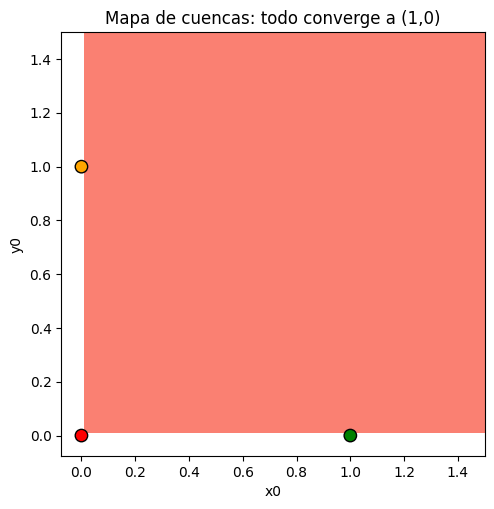

In [6]:
N = 60
gx = np.linspace(0.01, 1.5, N)
X0, Y0 = np.meshgrid(gx, gx)
S = np.array([X0.ravel(), Y0.ravel()])          # (2, 3600): RK4 vectorizado sobre toda la malla
Sf = rk4(f, S, 0.05, 200)

d10 = np.hypot(Sf[0] - 1, Sf[1]); d01 = np.hypot(Sf[0], Sf[1] - 1); d00 = np.hypot(Sf[0], Sf[1])
lab = np.full(Sf.shape[1], -1)
lab[d00 < 1e-3] = 0; lab[d01 < 1e-3] = 2; lab[d10 < 1e-3] = 1
print("sin clasificar:", int((lab == -1).sum()))
for k, n in {1: '(1,0)', 2: '(0,1)', 0: '(0,0)'}.items():
    print(f"fracción de la cuenca de {n}: {np.mean(lab == k):.4f}")

from matplotlib.colors import ListedColormap
plt.figure(figsize=(6, 5.5))
plt.imshow(lab.reshape(N, N), origin='lower', extent=[0.01, 1.5, 0.01, 1.5], cmap=ListedColormap(['gray', 'lightgreen', 'salmon', 'lightblue']), vmin=-1, vmax=2)
plt.scatter([1, 0, 0], [0, 1, 0], c=['green', 'orange', 'red'], edgecolors='k', s=80, zorder=5)
plt.xlabel('x0'); plt.ylabel('y0'); plt.title('Mapa de cuencas: todo converge a (1,0)'); plt.show()

**2.3b.** Cuenca de (1,0): 100 %. Cuenca de (0,1): 0 %. Cuenca de (0,0): 0 %.

**2.3c.** No aplica: solo hay un equilibrio estable.

**2.3d.** El mapa tiene un solo color. No hay interior factible y el sistema es competitivo en el plano (no hay órbitas periódicas), así que toda órbita acotada converge a un equilibrio. (0,0) es fuente y (0,1) es silla. La única trayectoria que llega a (0,1) está en su variedad estable, que es el eje x = 0. Los ejes son invariantes y ese eje queda fuera de la malla, por eso la cuenca de (0,1) tiene medida cero.

## Task 2.4: tasa de decaimiento y paso máximo de Euler

Equilibrio estable: (1,0), con λ = −1 y −0.35. Ocho direcciones θₖ = (k + ½)π/8 en el semiplano y ≥ 0, distancia 10⁻⁴.

autovalores en (1,0): [-1.   -0.35] | min|Re λ| = 0.35
autovector lento (normalizado): [-0.6782801   0.73480344]
 theta (°)  tasa medida  min|Re λ|  error relativo
      11.2       0.4102       0.35          0.1721
      33.8       0.3326       0.35          0.0497
      56.2       0.3305       0.35          0.0556
      78.8       0.3334       0.35          0.0475
     101.2       0.3378       0.35          0.0349
     123.7       0.3451       0.35          0.0140
     146.2       0.3629       0.35          0.0368
     168.8       0.4626       0.35          0.3216


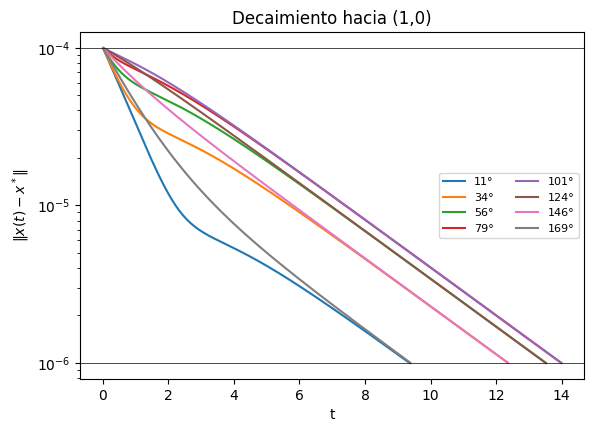

In [7]:
xs = np.array([1.0, 0.0])
Jxs = jac(*xs); lam, V = np.linalg.eig(Jxs)
lam_min = np.min(np.abs(lam.real))
print("autovalores en (1,0):", lam, "| min|Re λ| =", lam_min)
iv = np.argmax(lam)   # autovalor lento (-0.35)
print("autovector lento (normalizado):", V[:, iv] / np.linalg.norm(V[:, iv]))

rows, curvas = [], []
for k in range(8):
    th = (k + 0.5) * np.pi / 8
    s = xs + 1e-4 * np.array([np.cos(th), np.sin(th)]); h = 0.01; t = 0.0; ts, ns = [], []
    while True:
        s = rk4_step(f, s, h); t += h
        n = np.linalg.norm(s - xs); ts.append(t); ns.append(n)
        if n < 1e-6: break
    ts, ns = np.array(ts), np.array(ns); m = (ns <= 1e-4) & (ns >= 1e-6)
    tasa = -np.polyfit(ts[m], np.log(ns[m]), 1)[0]
    rows.append({'theta (°)': round(np.degrees(th), 1), 'tasa medida': tasa, 'min|Re λ|': lam_min, 'error relativo': abs(tasa - lam_min) / lam_min})
    curvas.append((th, ts, ns))
print(pd.DataFrame(rows).round(4).to_string(index=False))

plt.figure(figsize=(6.5, 4.5))
for th, ts, ns in curvas: plt.semilogy(ts, ns, label=f'{np.degrees(th):.0f}°')
plt.axhline(1e-4, color='k', lw=.5); plt.axhline(1e-6, color='k', lw=.5)
plt.xlabel('t'); plt.ylabel(r'$\|x(t)-x^*\|$'); plt.legend(ncol=2, fontsize=8); plt.title('Decaimiento hacia (1,0)'); plt.show()

**Transitorio:** el error es e(t) = c₁e⁻ᵗv₁ + c₂e⁻⁰·³⁵ᵗv₂. Las direcciones casi paralelas al eje x (≈ 11° y ≈ 169°) tienen la mayor componente sobre v₁ (λ = −1), así que su pendiente aparente es mayor mientras ese modo no se haya apagado. A tiempos largos solo sobrevive el modo lento y la tasa tiende a 0.35.

**Condición de Euler:** |1 + hλ|² < 1 ⇒ (1 + h·Reλ)² + h²(Imλ)² < 1 ⇒ **h < −2Reλ/|λ|²**.

In [8]:
h_i = -2 * lam.real / np.abs(lam)**2
print("h_max por autovalor:", dict(zip(np.round(lam.real, 3), np.round(h_i, 4))), "| h_max teórico =", h_i.min())

def converge(h, d0=1e-3, Tmax=2000.0):
    s = xs + np.array([d0, d0])
    for _ in range(int(Tmax / h)):
        s = s + h * f(s)
        if np.linalg.norm(s - xs) > 1e3: return False
    return np.linalg.norm(s - xs) < 1e-6

lo, hi = 0.5, 3.0
for _ in range(40):
    m = 0.5 * (lo + hi)
    if converge(m): lo = m
    else: hi = m
print(f"h_max numérico (bisección) ≈ {lo:.4f} | teórico = {h_i.min():.4f}")

h_max por autovalor: {np.float64(-1.0): np.float64(2.0), np.float64(-0.35): np.float64(5.7143)} | h_max teórico = 2.0
h_max numérico (bisección) ≈ 1.9925 | teórico = 2.0000


**Interpretación.** El valor numérico queda ligeramente por debajo del teórico. En h = 2 el multiplicador del modo rápido es 1 + hλ = −1 (marginal), y ahí los términos no lineales (−r₁x², −r₁α₁₂xy, …) deciden el signo del efecto, algo que la linealización no puede predecir. Lejos del equilibrio el Jacobiano local también es distinto, lo que reduce el paso estable.

## Task 2.5: intervenciones

Plataforma de interés: **B** (en este régimen termina con y → 0 partiendo de P2).

**a. Campaña de adquisición (Δ sobre y).** Como x₀ > 0 no cambia, el estado (x₀, y₀ + Δ) sigue fuera del eje x = 0, que es la variedad estable de la silla (0,1). Por la estructura de equilibrios (sin interior factible, (0,0) fuente) el destino es siempre (1,0). No existe un Δ mínimo.

In [9]:
for D in [0.1, 0.5, 1, 3, 10, 100]:
    print(f"Δ = {D:>6}: estado final desde (0.8, {0.3 + D}) →", rk4(f, (0.8, 0.3 + D), 0.01, 400).round(6))

# Bisección: ¿hay Δ en [0,100] donde cambie el destino (x final < 0.5)?
def destino_delta(D): return rk4(f, (0.8, 0.3 + D), 0.01, 400)[0] > 0.5
print("Δ=0 → gana A:", destino_delta(0.0), "| Δ=100 → gana A:", destino_delta(100.0), "→ sin cambio de destino, la bisección no tiene bracket")

Δ =    0.1: estado final desde (0.8, 0.4) → [1. 0.]
Δ =    0.5: estado final desde (0.8, 0.8) → [1. 0.]
Δ =      1: estado final desde (0.8, 1.3) → [1. 0.]
Δ =      3: estado final desde (0.8, 3.3) → [1. 0.]
Δ =     10: estado final desde (0.8, 10.3) → [1. 0.]
Δ =    100: estado final desde (0.8, 100.3) → [1. 0.]
Δ=0 → gana A: True | Δ=100 → gana A: True → sin cambio de destino, la bisección no tiene bracket


**b. Valor crítico de la rivalidad que frena a B: α₂₁\* = 1.** En (1,0) uno de los valores propios es λ = r₂(1 − α₂₁), que cambia de signo en α₂₁ = 1 (independiente de r₂). Para α₂₁ > 1, (1,0) es nodo estable (exclusión). Para α₂₁ < 1 pasa a silla y aparece el interior factible, que es nodo estable (α₁₂α₂₁ < 1): coexistencia.

α21 = 1.2: estado final = [1. 0.] | interior teórico = [ 1.42857 -0.71429]
α21 = 0.8: estado final = [0.76923 0.38462] | interior teórico = [0.76923 0.38462]


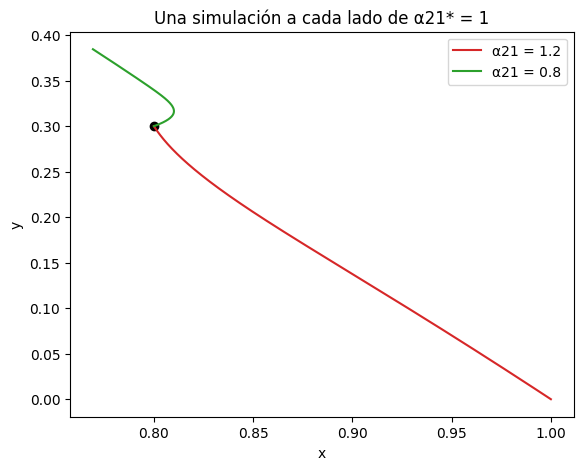

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 5))
for bb, c_ in [(1.2, 'tab:red'), (0.8, 'tab:green')]:
    fb = make_f(a, bb, r1, r2)
    sf = rk4(fb, P['P2'], 0.01, 300)
    teo = ((1 - a) / (1 - a * bb), (1 - bb) / (1 - a * bb))
    print(f"α21 = {bb}: estado final = {sf.round(5)} | interior teórico = {np.round(teo, 5)}")
    tr = rk4_traj(fb, P['P2'], 0.01, 60); ax.plot(tr[:, 0], tr[:, 1], c=c_, label=f'α21 = {bb}')
ax.scatter(*P['P2'], c='k'); ax.set_xlabel('x'); ax.set_ylabel('y'); ax.legend(); ax.set_title('Una simulación a cada lado de α21* = 1'); plt.show()

**c. Recomendación y robustez.** Se recomienda la **diferenciación de producto**, bajando α₂₁ claramente por debajo de 1. La campaña nunca cambia el destino: solo da un beneficio transitorio que decae con el tiempo de recuperación T = 1/0.35 ≈ 2.9.

La diferenciación sí cambia el régimen, pero es frágil si se queda cerca de α₂₁ = 1: ahí el valor propio r₂(1 − α₂₁) → 0, es decir, queda cerca del eje imaginario. El tiempo de recuperación 1/|λ| diverge (ralentización crítica) y un error pequeño en α₂₁ o en r₂ puede devolver el sistema a la exclusión. Para que sea robusta hay que apuntar bien por debajo de 1 (por ejemplo α₂₁ ≈ 0.6–0.8). La gráfica siguiente muestra T en función de α₂₁.

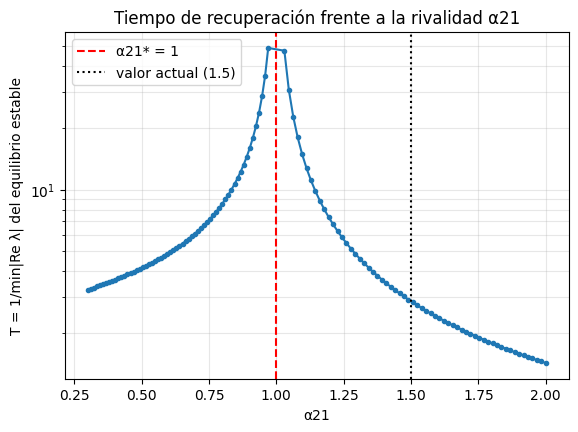

In [11]:
bs = np.concatenate([np.linspace(0.3, 0.97, 60), np.linspace(1.03, 2.0, 60)])
Tr = []
for bb in bs:
    if bb > 1:   # equilibrio estable (1,0): autovalores -r1 y r2(1-b)
        lams = np.array([-r1, r2 * (1 - bb)])
    else:        # equilibrio estable: interior
        dd = 1 - a * bb; xi, yi = (1 - a) / dd, (1 - bb) / dd
        lams = np.linalg.eigvals(jac(xi, yi, a, bb, r1, r2))
    Tr.append(1 / np.min(np.abs(lams.real)))

plt.figure(figsize=(6.5, 4.5))
plt.semilogy(bs, Tr, '.-'); plt.axvline(1, color='r', ls='--', label='α21* = 1')
plt.axvline(b, color='k', ls=':', label=f'valor actual ({b})')
plt.xlabel('α21'); plt.ylabel('T = 1/min|Re λ| del equilibrio estable'); plt.legend(); plt.grid(True, which='both', alpha=.3)
plt.title('Tiempo de recuperación frente a la rivalidad α21'); plt.show()